In [112]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit


In [ ]:
invariant_list = []
for i in trange(1000):
    qc = QuantumCircuit(2)
    qc.append(SwapGate().power(0.5), [0, 1])
    qc.append(
        UGate(
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
        ),
        [0],
    )
    qc.append(
        UGate(
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 2 * np.pi),
        ),
        [1],
    )
    qc.append(SwapGate().power(0.5), [0, 1])
    target = GateInvariants.from_unitary(Operator(qc))
    invariant_list.append(target)

from gulps.viz.invariant_viz import scatter_plot

scatter_plot(invariant_list)

In [113]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 3), 1 / 3, "sqrt3cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (SwapGate(), 0.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=False)
decomposer = GulpsDecomposer(isa=isa)

if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

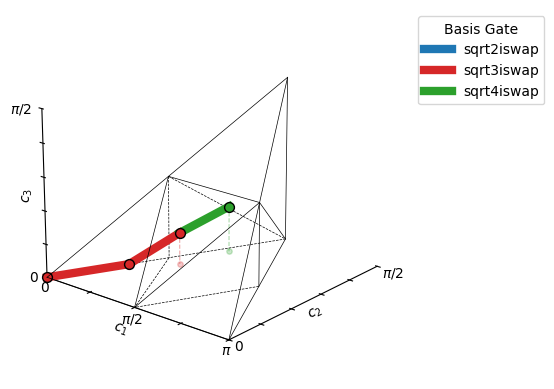

In [141]:
r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
fig = plot_decomposition(r.intermediates, r.sentence, isa)

In [115]:
# Create animation and save as GIF for PowerPoint (memory-efficient)
from PIL import Image
import io

images = []
for _i in trange(100, desc="Generating frames"):
    # Generate decomposition
    r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
    fig = plot_decomposition(r.intermediates, r.sentence, isa)

    # Immediately convert to PIL Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    img = Image.open(buf).copy()
    images.append(img)
    buf.close()

    # Close the figure immediately to free memory
    plt.close(fig)

# Save as GIF
output_path = "images/trajectory_animation.gif"
images[0].save(
    output_path,
    save_all=True,
    append_images=images[1:],
    duration=150,  # milliseconds per frame
    loop=0,  # infinite loop
)

print(f"✓ Saved animation to {output_path}")
print(f"  Frames: {len(images)}, Size: {images[0].size}")

# Clean up
for img in images:
    img.close()

Generating frames:   0%|          | 0/100 [00:00<?, ?it/s]

Generating frames:  22%|██▏       | 22/100 [00:02<00:09,  7.81it/s]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create animation with space-filling walk through Weyl chamber
from PIL import Image
import io


def generate_weyl_chamber_walk(n_points=100):
    """Generate a smooth walk through the Weyl chamber triangle.

    Coordinates are normalized to [0, 0.5] as per from_weyl method.
    Constraints: x >= y >= z >= 0 (triangular region in x-y plane)

    Strategy: Sweep z from 0 to 0.5, and for each z-layer,
    traverse the triangular region x >= y >= z using a serpentine pattern.
    """
    points = []

    # Number of z-layers to traverse
    n_z_layers = max(3, int(np.ceil(n_points**0.4)))
    points_per_layer = n_points // n_z_layers

    for z_idx in range(n_z_layers):
        z = 0.5 * z_idx / max(1, n_z_layers - 1)

        # For this z-layer, traverse the triangular region x >= y >= z
        # Use sqrt to get approximately square coverage in 2D
        n_rows = max(1, int(np.ceil(np.sqrt(points_per_layer))))

        layer_points = []
        for row_idx in range(n_rows):
            # y ranges from z to some max value
            # x ranges from y to 0.5
            y_frac = row_idx / max(1, n_rows - 1)
            y = z + (0.5 - z) * y_frac

            # Number of points in this row depends on available x-range
            x_range = 0.5 - y
            if x_range > 1e-10:
                n_cols = max(1, int(np.ceil(n_rows * (x_range / (0.5 - z)))))

                for col_idx in range(n_cols):
                    x_frac = col_idx / max(1, n_cols - 1)
                    x = y + (0.5 - y) * x_frac
                    layer_points.append((x, y, z))
            else:
                layer_points.append((y, y, z))

        # Reverse every other layer for serpentine pattern
        if z_idx % 2 == 1:
            layer_points.reverse()

        points.extend(layer_points)

    # Trim to exactly n_points
    return points[:n_points]


# Generate smooth walk through Weyl chamber
weyl_points = generate_weyl_chamber_walk(n_points=500)

images = []
for i, (c1, c2, c3) in enumerate(tqdm(weyl_points, desc="Generating frames")):
    # Use from_weyl to create invariants (expects normalized coords in [0, 0.5])
    inv = GateInvariants.from_weyl((c1, c2, c3))

    # Decompose
    r = decomposer._best_decomposition(inv)
    fig = plot_decomposition(r.intermediates, r.sentence, isa)

    # Immediately convert to PIL Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    img = Image.open(buf).copy()
    images.append(img)
    buf.close()

    # Close the figure immediately to free memory
    plt.close(fig)

# Save as GIF
output_path = "images/trajectory_animation.gif"
images[0].save(
    output_path,
    save_all=True,
    append_images=images[1:],
    duration=150,  # milliseconds per frame
    loop=0,  # infinite loop
)

print(f"✓ Saved animation to {output_path}")
print(f"  Frames: {len(images)}, Size: {images[0].size}")

# Clean up
for img in images:
    img.close()

Generating frames:   0%|          | 0/343 [00:00<?, ?it/s]

Generating frames: 100%|██████████| 343/343 [00:45<00:00,  7.49it/s]


✓ Saved animation to images/trajectory_animation.gif
  Frames: 343, Size: (554, 389)
